In [286]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import folium
import yaml
import numpy as np
import geopandas as gpd
from pyproj import Transformer
from shapely.geometry import Polygon
from folium import plugins
import requests
import os
from math import radians, cos, sin, asin, sqrt


import calliope

# We increase logging verbosity
calliope.set_log_verbosity("INFO", include_solver_output=False)

In [287]:

# Adjust links costs to a specified value
import pandas as pd

# Load links costs CSV
links_costs_df = pd.read_csv('links_costs.csv')

# Define cost value (user-adjustable)
cost_value = 100000000  # 100000000 for high, 0.01 for low

# Update the cost column
links_costs_adjusted = links_costs_df.copy()
links_costs_adjusted['cost_flow_cap_per_distance'] = cost_value


# Save to CSV
links_costs_adjusted.to_csv('links_costs.csv', index=False)
print(f"  All {len(links_costs_adjusted)} links now have cost: {cost_value:,.2f}")


  All 11 links now have cost: 100,000,000.00


In [288]:
model = calliope.read_yaml('model.yaml')

[2026-04-02 14:27:41] INFO     Math init | loading pre-defined math.
[2026-04-02 14:27:41] INFO     Math init | loading math files {'milp', 'spores', 'operate', 'storage_inter_cluster', 'base'}.
[2026-04-02 14:27:41] INFO     Model: preprocessing data
[2026-04-02 14:27:41] INFO     Math build | building applied math with ['base'].
[2026-04-02 14:27:42] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-04-02 14:27:42] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-04-02 14:27:42] INFO     input data `flow_cap` not defined in model math; it will not be available in the optimisation problem.
[2026-04-02 14:27:42] INFO     input data `link_to` not defined in model math; it will not be available in the optimisation problem.
[2026-04-02 14:27:42] INFO     input data `link_from` not defined in model math; it will not be available in the optimisation problem.
[202

In [289]:
model.inputs

<xarray.Dataset> Size: 463kB
Dimensions:                       (costs: 1, techs: 14, nodes: 12, carriers: 1,
                                   timesteps: 336)
Coordinates:
  * costs                         (costs) object 8B 'monetary'
  * techs                         (techs) object 112B 'HV_station_to_transmis...
  * carriers                      (carriers) object 8B 'electricity'
  * nodes                         (nodes) object 96B 'HV_station' ... 'transm...
  * timesteps                     (timesteps) datetime64[ns] 3kB 2024-09-01 ....
Data variables: (12/31)
    cost_interest_rate            (costs) float64 8B 0.1
    bigM                          float64 8B 1e+06
    objective_cost_weights        (costs) float64 8B 1.0
    base_tech                     (techs) object 112B 'transmission' ... 'tra...
    carrier_in                    (nodes, techs, carriers) bool 168B True ......
    color                         (techs) object 112B '#823739' ... '#823739'
    ...                            ...
    cost_flow_cap_per_distance    (costs, techs) float64 112B 1e+08 ... 1e+08
    sink_use_equals               (timesteps, techs, nodes) float64 452kB nan...
    definition_matrix             (nodes, techs, carriers) bool 168B True ......
    distance                      (techs) float64 112B 0.05581 nan ... 0.5484
    timestep_resolution           (timesteps) float64 3kB 1.0 1.0 ... 1.0 1.0
    timestep_weights              (timesteps) float64 3kB 1.0 1.0 ... 1.0 1.0

In [290]:
model.inputs.flow_cap_max.to_series().dropna()  

techs
HV_station_to_transmission_1            100000.0
supply_grid_power                        50000.0
transmission_1_to_transmission_2        100000.0
transmission_1_to_transmission_3        100000.0
transmission_2_to_data_center_3         100000.0
transmission_3_to_data_center_2         100000.0
transmission_3_to_transmission_4        100000.0
transmission_3_to_transmission_5        100000.0
transmission_4_to_data_center_1         100000.0
transmission_5_to_transmission_6        100000.0
transmission_6_to_transmission_7        100000.0
transmission_7_to_residential_demand    100000.0
Name: flow_cap_max, dtype: float64

In [291]:
model.inputs.sink_use_equals.sum(
    "timesteps", min_count=1, skipna=True
).to_series().dropna()

techs               nodes             
demand_electricity  data_center_1         1.680000e+06
                    data_center_2         2.688000e+06
                    data_center_3         4.032000e+06
                    residential_demand    2.233275e+05
Name: sink_use_equals, dtype: float64

In [292]:
model.build(force=True)

[2026-04-02 14:27:42] INFO     Model: backend build starting
[2026-04-02 14:27:42] INFO     Optimisation Model | parameters/lookups | Generated.
[2026-04-02 14:27:43] INFO     Optimisation Model | variables | Generated.
[2026-04-02 14:27:44] INFO     Optimisation Model | global_expressions | Generated.
[2026-04-02 14:27:48] INFO     Optimisation Model | constraints | Generated.
[2026-04-02 14:27:48] INFO     Optimisation Model | piecewise_constraints | Generated.
[2026-04-02 14:27:48] INFO     Optimisation Model | objectives | Generated.
[2026-04-02 14:27:48] INFO     Model: backend build complete


In [293]:
model.backend.parameters

<xarray.Dataset> Size: 462kB
Dimensions:                             (costs: 1, techs: 14, timesteps: 336,
                                         nodes: 12)
Coordinates:
  * costs                               (costs) object 8B 'monetary'
  * techs                               (techs) object 112B 'HV_station_to_tr...
  * nodes                               (nodes) object 96B 'HV_station' ... '...
  * timesteps                           (timesteps) datetime64[ns] 3kB 2024-0...
Data variables: (12/59)
    area_use_max                        float64 8B nan
    area_use_min                        float64 8B nan
    area_use_per_flow_cap               float64 8B nan
    available_area                      float64 8B nan
    bigM                                object 8B parameters[bigM][0]
    cost_flow_cap_per_distance          (costs, techs) object 112B parameters...
    ...                                  ...
    storage_cap_per_unit                float64 8B nan
    storage_discharge_depth             float64 8B nan
    storage_initial                     float64 8B nan
    storage_loss                        (techs) object 112B nan ... nan
    timestep_resolution                 (timesteps) object 3kB parameters[tim...
    timestep_weights                    (timesteps) object 3kB parameters[tim...

In [294]:
model.solve(solver='gurobi')

[2026-04-02 14:27:48] INFO     Optimisation model | starting model in base mode.
[2026-04-02 14:27:50] INFO     Backend: solver finished running. Time since start of solving optimisation problem: 0:00:02.022541
[2026-04-02 14:27:51] INFO     Postprocessing: applied zero threshold 1e-10 to model results.
[2026-04-02 14:27:51] INFO     Postprocessing: ended. Time since start of solving optimisation problem: 0:00:02.085019
[2026-04-02 14:27:51] INFO     Backend: model solve completed. Time since start of solving optimisation problem: 0:00:02.086523


In [295]:
model.backend.parameters

<xarray.Dataset> Size: 462kB
Dimensions:                             (costs: 1, techs: 14, timesteps: 336,
                                         nodes: 12)
Coordinates:
  * costs                               (costs) object 8B 'monetary'
  * techs                               (techs) object 112B 'HV_station_to_tr...
  * nodes                               (nodes) object 96B 'HV_station' ... '...
  * timesteps                           (timesteps) datetime64[ns] 3kB 2024-0...
Data variables: (12/59)
    area_use_max                        float64 8B nan
    area_use_min                        float64 8B nan
    area_use_per_flow_cap               float64 8B nan
    available_area                      float64 8B nan
    bigM                                object 8B parameters[bigM][0]
    cost_flow_cap_per_distance          (costs, techs) object 112B parameters...
    ...                                  ...
    storage_cap_per_unit                float64 8B nan
    storage_discharge_depth             float64 8B nan
    storage_initial                     float64 8B nan
    storage_loss                        (techs) object 112B nan ... nan
    timestep_resolution                 (timesteps) object 3kB parameters[tim...
    timestep_weights                    (timesteps) object 3kB parameters[tim...

In [296]:
model.results

<xarray.Dataset> Size: 3MB
Dimensions:                      (nodes: 12, techs: 14, carriers: 1,
                                  timesteps: 336, costs: 1)
Coordinates:
  * techs                        (techs) object 112B 'HV_station_to_transmiss...
  * nodes                        (nodes) object 96B 'HV_station' ... 'transmi...
  * carriers                     (carriers) object 8B 'electricity'
  * timesteps                    (timesteps) datetime64[ns] 3kB 2024-09-01 .....
  * costs                        (costs) object 8B 'monetary'
Data variables: (12/23)
    flow_cap                     (nodes, techs, carriers) float64 1kB 2.577e+...
    link_flow_cap                (techs) float64 112B 2.577e+04 nan ... 674.5
    flow_out                     (nodes, techs, carriers, timesteps) float64 452kB ...
    flow_in                      (nodes, techs, carriers, timesteps) float64 452kB ...
    source_use                   (nodes, techs, timesteps) float64 452kB nan ...
    source_cap                   (nodes, techs) float64 1kB nan nan ... nan nan
    ...                           ...
    min_cost_optimisation        float64 8B 4.628e+09
    capacity_factor              (nodes, techs, carriers, timesteps) float64 452kB ...
    systemwide_capacity_factor   (techs, carriers) float64 112B 0.4997 ... 0....
    systemwide_levelised_cost    (techs, costs, carriers) float64 112B 74.87 ...
    total_levelised_cost         (costs, carriers) float64 8B 534.4
    unmet_sum                    (nodes, carriers, timesteps) float64 32kB 0....

In [297]:
costs = model.results.cost.to_series().dropna()
costs.head()

nodes          techs                            costs   
HV_station     HV_station_to_transmission_1     monetary    3.240186e+08
               supply_grid_power                monetary    1.089108e+02
data_center_1  transmission_4_to_data_center_1  monetary    2.645240e+08
data_center_2  transmission_3_to_data_center_2  monetary    4.356760e+08
data_center_3  transmission_2_to_data_center_3  monetary    8.578131e+07
Name: cost, dtype: float64

In [298]:
lcoes = (
    model.results.systemwide_levelised_cost.sel(carriers="electricity")
    .to_series()
    .dropna()
)
lcoes.head()

techs                             costs   
HV_station_to_transmission_1      monetary     74.872855
battery                           monetary      0.000004
supply_grid_power                 monetary      0.000013
transmission_1_to_transmission_2  monetary     38.951795
transmission_1_to_transmission_3  monetary    175.669458
Name: systemwide_levelised_cost, dtype: float64

In [299]:
# We set the color mapping to use in all our plots by extracting the colors defined in the technology definitions of our model.
colors = model.inputs.color.to_series().to_dict()

In [300]:
df_electricity = (
    (model.results.flow_out.fillna(0) - model.results.flow_in.fillna(0))
    .sel(carriers="electricity")
    .sum("nodes")
    .to_series()
    .where(lambda x: x != 0)
    .dropna()
    .to_frame("Flow in/out (kWh)")
    .reset_index()
)
df_electricity_demand = df_electricity[df_electricity.techs == "demand_electricity"]
df_electricity_other = df_electricity[df_electricity.techs != "demand_electricity"]

print(df_electricity.head())

fig1 = px.bar(
    df_electricity_other,
    x="timesteps",
    y="Flow in/out (kWh)",
    color="techs",
    color_discrete_map=colors,
)
fig1.add_scatter(
    x=df_electricity_demand.timesteps,
    y=-1 * df_electricity_demand["Flow in/out (kWh)"],
    marker_color="black",
    name="demand",
)
fig1.show()

                          techs           timesteps  Flow in/out (kWh)
0  HV_station_to_transmission_1 2024-09-01 00:00:00         -14.452232
1  HV_station_to_transmission_1 2024-09-01 01:00:00         -14.452232
2  HV_station_to_transmission_1 2024-09-01 02:00:00         -14.452232
3  HV_station_to_transmission_1 2024-09-01 03:00:00         -14.452232
4  HV_station_to_transmission_1 2024-09-01 04:00:00         -14.452232


In [301]:
carriers = ["electricity"]
df_flows = (
    (model.results.flow_out.fillna(0) - model.results.flow_in.fillna(0))
    .sel(carriers=carriers)
    .to_series()
    .where(lambda x: x != 0)
    .dropna()
    .to_frame("Flow in/out (kWh)")
    .reset_index()
)
df_demand = df_flows[df_flows.techs.str.contains("demand")]
df_flows_other = df_flows[~df_flows.techs.str.contains("demand")]

print(df_flows.head())

node_order = df_flows_other.nodes.unique()

fig = px.bar(
    df_flows_other,
    x="timesteps",
    y="Flow in/out (kWh)",
    facet_row="nodes",
    facet_col="carriers",
    color="techs",
    category_orders={"nodes": node_order, "carriers": carriers},
    height=1000,
    color_discrete_map=colors,
)

showlegend = True
# we reverse the node order (`[::-1]`) because the rows are numbered from bottom to top.
for row, node in enumerate(node_order[::-1]):
    for col, carrier in enumerate(carriers):
        demand_ = df_demand.loc[
            (df_demand.nodes == node) & (df_demand.techs == f"demand_{carrier}"),
            "Flow in/out (kWh)",
        ]
        if not demand_.empty:
            fig.add_scatter(
                x=model.results.timesteps.values,
                y=-1 * demand_,
                row=row + 1,
                col=col + 1,
                marker_color="black",
                name="Demand",
                legendgroup="demand",
                showlegend=showlegend,
            )
            showlegend = False
fig.update_yaxes(matches=None)
fig.show()

        nodes                         techs     carriers           timesteps  \
0  HV_station  HV_station_to_transmission_1  electricity 2024-09-01 00:00:00   
1  HV_station  HV_station_to_transmission_1  electricity 2024-09-01 01:00:00   
2  HV_station  HV_station_to_transmission_1  electricity 2024-09-01 02:00:00   
3  HV_station  HV_station_to_transmission_1  electricity 2024-09-01 03:00:00   
4  HV_station  HV_station_to_transmission_1  electricity 2024-09-01 04:00:00   

   Flow in/out (kWh)  
0      -25773.882466  
1      -25773.882466  
2      -25773.882466  
3      -25773.882466  
4      -25773.882466  


In [302]:
df_capacity = (
    model.results.flow_cap.where(
        ~model.inputs.base_tech.str.contains("demand|transmission")
    )
    .to_series()
    .where(lambda x: x != 0)
    .dropna()
    .to_frame("Flow capacity (kW)")
    .reset_index()
)

print(df_capacity.head())

fig = px.bar(
    df_capacity,
    x="nodes",
    y="Flow capacity (kW)",
    color="techs",
    facet_col="carriers",
    color_discrete_map=colors,
)
fig.show()

                nodes              techs     carriers  Flow capacity (kW)
0          HV_station  supply_grid_power  electricity        25773.882466
1  residential_demand            battery  electricity          413.040727


In [303]:
with open("model.yaml", "r", encoding="utf-8") as f:
    model_def = yaml.safe_load(f)

node_techs = {
    node: list((node_data.get("techs") or {}).keys())
    for node, node_data in model_def.get("nodes", {}).items()
}

In [313]:
# Build a simple system map (nodes + links)
nodes = pd.read_csv("nodes_coordinates.csv")
links = pd.read_csv("links_techs.csv")

flow_cap = (
    model.results.flow_cap.to_series().dropna()
    .to_frame("Flow capacity (kW)")
    .reset_index()
)
flow_cap_lookup = dict(zip(flow_cap["techs"], flow_cap["Flow capacity (kW)"]))

center = [nodes.latitude.mean(), nodes.longitude.mean()]
system_map = folium.Map(location=center, zoom_start=15, tiles="CartoDB voyager")

# Add link lines for transmission network
for _, row in links.iterrows():
    from_row = nodes.loc[nodes.nodes == row["link_from"]].iloc[0]
    to_row = nodes.loc[nodes.nodes == row["link_to"]].iloc[0]
    capacity = flow_cap_lookup.get(row["techs"], row.get("flow_cap_max"))
    popup = (
        f"<b>{row['techs']}</b><br>From: {row['link_from']}<br>To: {row['link_to']}"
    )
    if capacity is not None:
        popup += f"<br>Capacity: {capacity:.2f} kW"
    folium.PolyLine(
        locations=[[from_row.latitude, from_row.longitude], [to_row.latitude, to_row.longitude]],
        color="#184e47",
        weight=3,
        opacity=1,
        popup=popup,
    ).add_to(system_map)

# Add node markers with colors based on node type
color_map = model.inputs.color.to_series().to_dict()
for _, row in nodes.iterrows():
    node = row["nodes"]
    techs = node_techs.get(node, [])
    base_types = (
        model.inputs.base_tech.sel(techs=techs).to_series().to_dict()
        if techs
        else {}
    )

    node_type = "Other"
    if any(t == "demand" for t in base_types.values()):
        node_type = "Demand"
        marker_color = "#82d89a"
    elif any(t == "supply" for t in base_types.values()):
        node_type = "Supply"
        marker_color = "#002022"
    else:
        node_type = "Transmission"
        marker_color = "#184e47"

    popup = f"<b>{node}</b> ({node_type})<br>Techs: {', '.join(techs)}"
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=6,
        color=marker_color,
        fill=True,
        fillColor=marker_color,
        fillOpacity=1,
        popup=popup,
    ).add_to(system_map)

# Add legend
legend_html = '''
<div style="position: fixed; 
            bottom: 50px; right: 50px; width: 200px; height: 180px; 
            background-color: white; border:2px solid grey; z-index:9999; 
            font-size:14px; padding: 10px">
    <p style="margin: 0 0 10px 0; font-weight: bold;">Legend</p>
    <p style="margin: 5px 0;"><i class="fa fa-circle" style="color:#82d89a"></i> Demand Nodes</p>
    <p style="margin: 5px 0;"><i class="fa fa-circle" style="color:#002022"></i> Supply Nodes</p>
    <p style="margin: 5px 0;"><i class="fa fa-circle" style="color:#184e47"></i> Transmission Nodes</p>
    <p style="margin: 5px 0;"><span style="color:#184e47; font-weight: bold;">—</span> Transmission Links</p>
</div>
'''
system_map.get_root().html.add_child(folium.Element(legend_html))

system_map.save("system_map.html")

In [305]:
# Export Comprehensive Bill of Materials (All Technologies + Transmission)

def haversine_distance(lat1, lon1, lat2, lon2):
    """Calculate the great circle distance between two points on earth"""
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a))
    r = 6371000  # Radius of earth in meters
    return c * r

# ===== Non-transmission Technologies (Supply, Storage, etc.) =====
non_transmission_bom = (
    model.results.flow_cap
    .where(~model.inputs.base_tech.isin(["demand", "transmission"]))
    .to_series()
    .where(lambda x: x > 0)
    .dropna()
    .to_frame("capacity_kw")
    .reset_index()
)
non_transmission_bom = non_transmission_bom.rename(columns={"techs": "technology"})
non_transmission_bom["distance_m"] = None
non_transmission_bom["storage_capacity_kwh"] = None

# ===== Storage Technologies (Battery) =====
# Extract storage capacity for technologies that have it
storage_cap_data = (
    model.results.storage_cap
    .to_series()
    .where(lambda x: x > 0)
    .dropna()
    .to_frame("storage_capacity_kwh")
    .reset_index()
)
storage_cap_data = storage_cap_data.rename(columns={"techs": "technology"})

# For storage, set flow_cap (power) to NaN and distance_m to None
storage_cap_data["capacity_kw"] = None
storage_cap_data["distance_m"] = None

# Merge storage capacity back into non-transmission BOM
non_transmission_bom = non_transmission_bom.merge(
    storage_cap_data,
    on=["nodes", "technology"],
    how="left",
    suffixes=("", "_storage")
)

# Combine storage_capacity_kwh columns (one from initialization, one from merge)
if "storage_capacity_kwh_storage" in non_transmission_bom.columns:
    non_transmission_bom["storage_capacity_kwh"] = (
        non_transmission_bom["storage_capacity_kwh"]
        .where(non_transmission_bom["storage_capacity_kwh"].notna(), 
               non_transmission_bom["storage_capacity_kwh_storage"])
    )
    non_transmission_bom = non_transmission_bom.drop(columns=["storage_capacity_kwh_storage"])

# Update capacity_kw for storage technologies (set 0 to NaN)
non_transmission_bom.loc[non_transmission_bom["capacity_kw"] <= 0, "capacity_kw"] = None

# ===== Transmission Technologies (Power Lines) =====
power_lines_cap = (
    model.results.flow_cap
    .where(model.inputs.base_tech == "transmission")
    .to_series()
    .where(lambda x: x > 0)
    .dropna()
    .to_frame("capacity_kw")
    .reset_index()
)
power_lines_cap = power_lines_cap.groupby("techs", as_index=False)["capacity_kw"].first()

# Load links and coordinates to calculate distances
links_data = pd.read_csv("links_techs.csv")
nodes_coords = pd.read_csv("nodes_coordinates.csv")
coord_dict = dict(zip(nodes_coords['nodes'], zip(nodes_coords['latitude'], nodes_coords['longitude'])))

# Calculate distances
links_data['distance_m'] = links_data.apply(
    lambda row: haversine_distance(
        coord_dict[row['link_from']][0], coord_dict[row['link_from']][1],
        coord_dict[row['link_to']][0], coord_dict[row['link_to']][1]
    ),
    axis=1
)

# Merge transmission capacity with distances
transmission_bom = power_lines_cap.merge(
    links_data[["techs", "distance_m"]],
    left_on="techs",
    right_on="techs",
    how="left"
)
transmission_bom = transmission_bom.rename(columns={"techs": "technology"})

# ===== Combine All Technologies =====
# Ensure transmission_bom has all required columns
if "nodes" not in transmission_bom.columns:
    transmission_bom["nodes"] = None
if "storage_capacity_kwh" not in transmission_bom.columns:
    transmission_bom["storage_capacity_kwh"] = None

# Reorder columns consistently
required_columns = ["nodes", "technology", "capacity_kw", "distance_m", "storage_capacity_kwh"]
non_transmission_bom = non_transmission_bom[required_columns]
transmission_bom = transmission_bom[required_columns]

# Explicitly ensure distance_m and storage_capacity_kwh are float64 before concatenating
non_transmission_bom['distance_m'] = non_transmission_bom['distance_m'].astype('float64')
transmission_bom['distance_m'] = transmission_bom['distance_m'].astype('float64')
non_transmission_bom['capacity_kw'] = non_transmission_bom['capacity_kw'].astype('float64')
transmission_bom['capacity_kw'] = transmission_bom['capacity_kw'].astype('float64')
non_transmission_bom['storage_capacity_kwh'] = non_transmission_bom['storage_capacity_kwh'].astype('float64')
transmission_bom['storage_capacity_kwh'] = transmission_bom['storage_capacity_kwh'].astype('float64')

bom_df = pd.concat([non_transmission_bom, transmission_bom], ignore_index=True)

# Sort by technology name and capacity (handle NaN values)
bom_df = bom_df.sort_values(
    by=["technology", "capacity_kw"],
    ascending=[True, False],
    na_position='last'
).reset_index(drop=True)

# Save to single comprehensive CSV
os.makedirs("outputs", exist_ok=True)
bom_df.to_csv("outputs/bill_of_materials.csv", index=False)
#print(f"\nSaved to outputs/bill_of_materials.csv")

In [306]:

# Extract dispatch data for visualization
import numpy as np

# Extract timesteps
timesteps = model.results.timesteps.values
print(f"Timesteps: {len(timesteps)} values")
#print(timesteps)

# Extract grid power (supply_grid_power flow_out)
grid_power_data = model.results.flow_out.sel(techs="supply_grid_power", carriers="electricity").to_series().dropna()
grid_power = grid_power_data.values
print(f"\nGrid Power: min={grid_power.min():.1f}, max={grid_power.max():.1f} kW")

# Extract PV dispatch (pv flow_out)
pv_data = model.results.flow_out.sel(techs="pv", carriers="electricity").to_series().dropna()
pv_dispatch = pv_data.values
print(f"PV Dispatch: min={pv_dispatch.min():.1f}, max={pv_dispatch.max():.1f} kW")

# Extract battery dispatch (net flow: out - in), summed across all nodes
battery_out = model.results.flow_out.sel(techs="battery", carriers="electricity").to_series().dropna()
battery_in = model.results.flow_in.sel(techs="battery", carriers="electricity").to_series().dropna()
# Sum across all nodes by grouping by timesteps
battery_dispatch_series = (battery_out - battery_in).groupby('timesteps').sum()
battery_dispatch = battery_dispatch_series.values
print(f"Battery Dispatch (total across all nodes): min={battery_dispatch.min():.1f}, max={battery_dispatch.max():.1f} kW")


Timesteps: 336 values

Grid Power: min=25773.9, max=25773.9 kW


KeyError: "not all values found in index 'techs'. Try setting the `method` keyword argument (example: method='nearest')."

In [307]:
# ===== Extract prices from CSV =====
# Load electricity prices from the day_ahead_prices.csv file
try:
    prices_csv = pd.read_csv('day_ahead_prices.csv')
    print("CSV columns:", prices_csv.columns.tolist())
    print("CSV dtypes:\n", prices_csv.dtypes)
    print("\nFull CSV:")
    print(prices_csv)
    
    # The alabala column contains the prices
    if 'alabala' in prices_csv.columns:
        # Convert to numeric
        prices_values = pd.to_numeric(prices_csv['alabala'], errors='coerce')
        # Skip the first row (header/tech info) and get prices for timesteps
        day_ahead_prices_corrected = prices_values[1:].reset_index(drop=True).values[:len(timesteps)]
    else:
        day_ahead_prices_corrected = None
except Exception as e:
    print(f"Error loading prices: {e}")
    import traceback
    traceback.print_exc()
    day_ahead_prices_corrected = None

CSV columns: ['comment', 'alabala']
CSV dtypes:
 comment     object
alabala    float64
dtype: object

Full CSV:
                  comment       alabala
0                   techs           NaN
1     2024-01-01 00:00:00  1.000000e-05
2     2024-01-01 01:00:00  1.000000e-06
3     2024-01-01 02:00:00  0.000000e+00
4     2024-01-01 03:00:00 -1.000000e-06
...                   ...           ...
8779  2024-12-31 19:00:00  7.056000e-03
8780  2024-12-31 20:00:00  5.990000e-03
8781  2024-12-31 21:00:00  1.820000e-03
8782  2024-12-31 22:00:00  9.060000e-04
8783  2024-12-31 23:00:00  5.200000e-05

[8784 rows x 2 columns]


In [308]:
# ===== Improved Plot with Better Visibility =====
# Create a multi-row layout with separate scales for each component
fig_improved = make_subplots(
    rows=4, cols=1,
    shared_xaxes=True,
    subplot_titles=("Grid Power Supply", "PV Generation", "Battery Dispatch", "Spot Prices"),
    row_heights=[0.25, 0.2, 0.2, 0.35],
    vertical_spacing=0.08,
    specs=[[{}], [{}], [{}], [{}]]
)

# === Row 1: Grid Power (zoomed to actual range to show variations) ===
fig_improved.add_trace(
    go.Scatter(
        x=timesteps,
        y=grid_power,
        name="Grid Power",
        mode='lines',
        line=dict(color='#184e47', width=2.5),
        fill='tozeroy',
        fillcolor='rgba(24, 78, 71, 0.2)',
        hovertemplate='<b>%{x}</b><br>Grid Power: %{y:.1f} kW<extra></extra>'
    ),
    row=1, col=1
)

# === Row 2: PV Generation (smaller scale) ===
fig_improved.add_trace(
    go.Scatter(
        x=timesteps,
        y=pv_dispatch,
        name="PV",
        mode='lines',
        line=dict(color='#184e47', width=2.5),
        fill='tozeroy',
        fillcolor='rgba(24, 78, 71, 0.2)',
        hovertemplate='<b>%{x}</b><br>PV: %{y:.1f} kW<extra></extra>'
    ),
    row=2, col=1
)

# === Row 3: Battery (can be positive or negative) ===
# Add a zero line for reference
fig_improved.add_hline(y=0, line_dash="dash", line_color="gray", opacity=0.5, row=3, col=1)

fig_improved.add_trace(
    go.Scatter(
        x=timesteps,
        y=battery_dispatch,
        name="Battery",
        mode='lines',
        line=dict(color='#184e47', width=2.5),
        fill='tozeroy',
        fillcolor='rgba(24, 78, 71, 0.2)',
        hovertemplate='<b>%{x}</b><br>Battery: %{y:.1f} kW<extra></extra>'
    ),
    row=3, col=1
)

# === Row 4: Prices ===
if day_ahead_prices_corrected is not None:
    fig_improved.add_trace(
        go.Scatter(
            x=timesteps,
            y=day_ahead_prices_corrected,
            name="Day-Ahead Price",
            mode='lines+markers',
            line=dict(color='#184e47', width=2.5),
            marker=dict(size=4, color='#184e47'),
            fill='tozeroy',
            fillcolor='rgba(24, 78, 71, 0.2)',
            hovertemplate='<b>%{x}</b><br>Price: €%{y:.3f}/kWh<extra></extra>'
        ),
        row=4, col=1
    )

# Update y-axes labels and ranges
fig_improved.update_yaxes(title_text="Power (kW)", row=1, col=1)
fig_improved.update_yaxes(title_text="Power (kW)", row=2, col=1)
fig_improved.update_yaxes(title_text="Power (kW)", row=3, col=1)
if day_ahead_prices_corrected is not None:
    fig_improved.update_yaxes(title_text="Price (€/kWh)", row=4, col=1)

# Set appropriate y-axis range for grid power to show small variations
grid_power_min = grid_power.min()
grid_power_max = grid_power.max()
grid_power_margin = (grid_power_max - grid_power_min) * 0.1  # 10% margin
fig_improved.update_yaxes(
    range=[grid_power_min - grid_power_margin, grid_power_max + grid_power_margin],
    row=1, col=1
)

fig_improved.update_xaxes(title_text="Time", row=4, col=1)

fig_improved.update_layout(
    title="Energy Dispatch and Prices (Separate Scales)",
    height=840,
    hovermode='x unified',
    showlegend=True,
    template='plotly_white'
)

fig_improved.show()

print(f"\n✓ Improved visualization created with separate scales:")
print(f"  Grid Power range: {grid_power_min:.0f} - {grid_power_max:.0f} kW (zoomed to show variations)")
print(f"  PV scale: 0 - {pv_dispatch.max():.0f} kW")
print(f"  Battery scale: {battery_dispatch.min():.0f} - {battery_dispatch.max():.0f} kW")


✓ Improved visualization created with separate scales:
  Grid Power range: 25774 - 25774 kW (zoomed to show variations)
  PV scale: 0 - 605 kW
  Battery scale: -1471 - 1312 kW


In [309]:
# ===== Correlation Visualization Alternatives =====
from scipy import stats

# Ensure both arrays have same length
min_len = min(len(battery_dispatch), len(day_ahead_prices_corrected))
battery_trunc = battery_dispatch[:min_len]
price_trunc = day_ahead_prices_corrected[:min_len]
time_trunc = timesteps[:min_len]

# ===== ALTERNATIVE 2: Normalized Dual-Axis =====
batt_norm = (battery_trunc - battery_trunc.min()) / (battery_trunc.max() - battery_trunc.min())
price_norm = (price_trunc - price_trunc.min()) / (price_trunc.max() - price_trunc.min())

fig_dual = make_subplots(specs=[[{"secondary_y": True}]])
fig_dual.add_trace(
    go.Scatter(x=time_trunc, y=price_norm, name="Price", line=dict(color='#d62728', width=2.5)),
    secondary_y=False
)
fig_dual.add_trace(
    go.Scatter(x=time_trunc, y=batt_norm, name="Battery", line=dict(color='#2ca02c', width=2.5)),
    secondary_y=True
)
fig_dual.update_yaxes(title_text="Normalized Price", secondary_y=False)
fig_dual.update_yaxes(title_text="Normalized Battery", secondary_y=True)
fig_dual.update_layout(
    title="Dual-Axis: Direct temporal comparison (both normalized 0-1)",
    height=300,
    hovermode='x unified',
    template='plotly_white'
)
fig_dual.show()

In [310]:

# ===== Extract Residential Demand Data =====
# Extract residential demand using the transmission link flow_out (power delivered to residential demand)
try:
    # Get all transmission-to-residential-demand techs
    all_techs = model.results.techs.values
    res_demand_techs = [t for t in all_techs if 'residential_demand' in t.lower()]
    
    if res_demand_techs:
        # Extract flow_out from the transmission links to residential demand
        residential_demand_data = model.results.flow_out.sel(techs=res_demand_techs, carriers="electricity").sum(dim='techs')
        # Sum across all nodes to get total residential demand
        residential_demand_data = residential_demand_data.sum(dim='nodes')
        residential_demand = residential_demand_data.to_series().dropna().values
        print(f"Residential Demand (from transmission flows): min={residential_demand.min():.1f}, max={residential_demand.max():.1f} kW")
    else:
        residential_demand = None
        print("No residential demand techs found")
except Exception as e:
    print(f"Error extracting residential demand: {e}")
    import traceback
    traceback.print_exc()
    residential_demand = None

# Battery dispatch (already extracted earlier)
print(f"Battery Dispatch: min={battery_dispatch.min():.1f}, max={battery_dispatch.max():.1f} kW")

# Verify data availability
if residential_demand is not None:
    min_len_rbd = min(len(residential_demand), len(battery_dispatch))
    residential_demand_trunc = residential_demand[:min_len_rbd]
    battery_dispatch_trunc = battery_dispatch[:min_len_rbd]
    time_trunc_rbd = timesteps[:min_len_rbd]
    print(f"\nData aligned for analysis: {min_len_rbd} timesteps")


Residential Demand (from transmission flows): min=670.8, max=670.8 kW
Battery Dispatch: min=-1471.3, max=1312.3 kW

Data aligned for analysis: 336 timesteps


In [311]:
# ===== Normalized Dual-Axis Plot: Direct Temporal Comparison =====

if residential_demand is not None:
    # Normalize both signals to 0-1 range
    demand_norm = (residential_demand_trunc - residential_demand_trunc.min()) / (residential_demand_trunc.max() - residential_demand_trunc.min())
    batt_norm_rbd = (battery_dispatch_trunc - battery_dispatch_trunc.min()) / (battery_dispatch_trunc.max() - battery_dispatch_trunc.min())

    fig_dual_rbd = make_subplots(specs=[[{"secondary_y": True}]])
    
    fig_dual_rbd.add_trace(
        go.Scatter(
            x=time_trunc_rbd, 
            y=demand_norm, 
            name="Residential Demand", 
            line=dict(color='#82d89a', width=2.5),
            fill='tozeroy',
            fillcolor='rgba(130, 216, 154, 0.2)'
        ),
        secondary_y=False
    )
    
    fig_dual_rbd.add_trace(
        go.Scatter(
            x=time_trunc_rbd, 
            y=batt_norm_rbd, 
            name="Battery Dispatch", 
            line=dict(color='#184e47', width=2.5),
            fill='tozeroy',
            fillcolor='rgba(24, 78, 71, 0.2)'
        ),
        secondary_y=True
    )
    
    fig_dual_rbd.update_yaxes(title_text="Normalized demand", secondary_y=False)
    fig_dual_rbd.update_yaxes(title_text="Normalized battery", secondary_y=True)
    
    fig_dual_rbd.update_layout(
        title="Dual-Axis: Normalized Residential Demand vs Battery Dispatch (direct temporal comparison)",
        height=300,
        hovermode='x unified',
        template='plotly_white'
    )
    
    fig_dual_rbd.show()
    print("✓ Normalized dual-axis plot created")

✓ Normalized dual-axis plot created


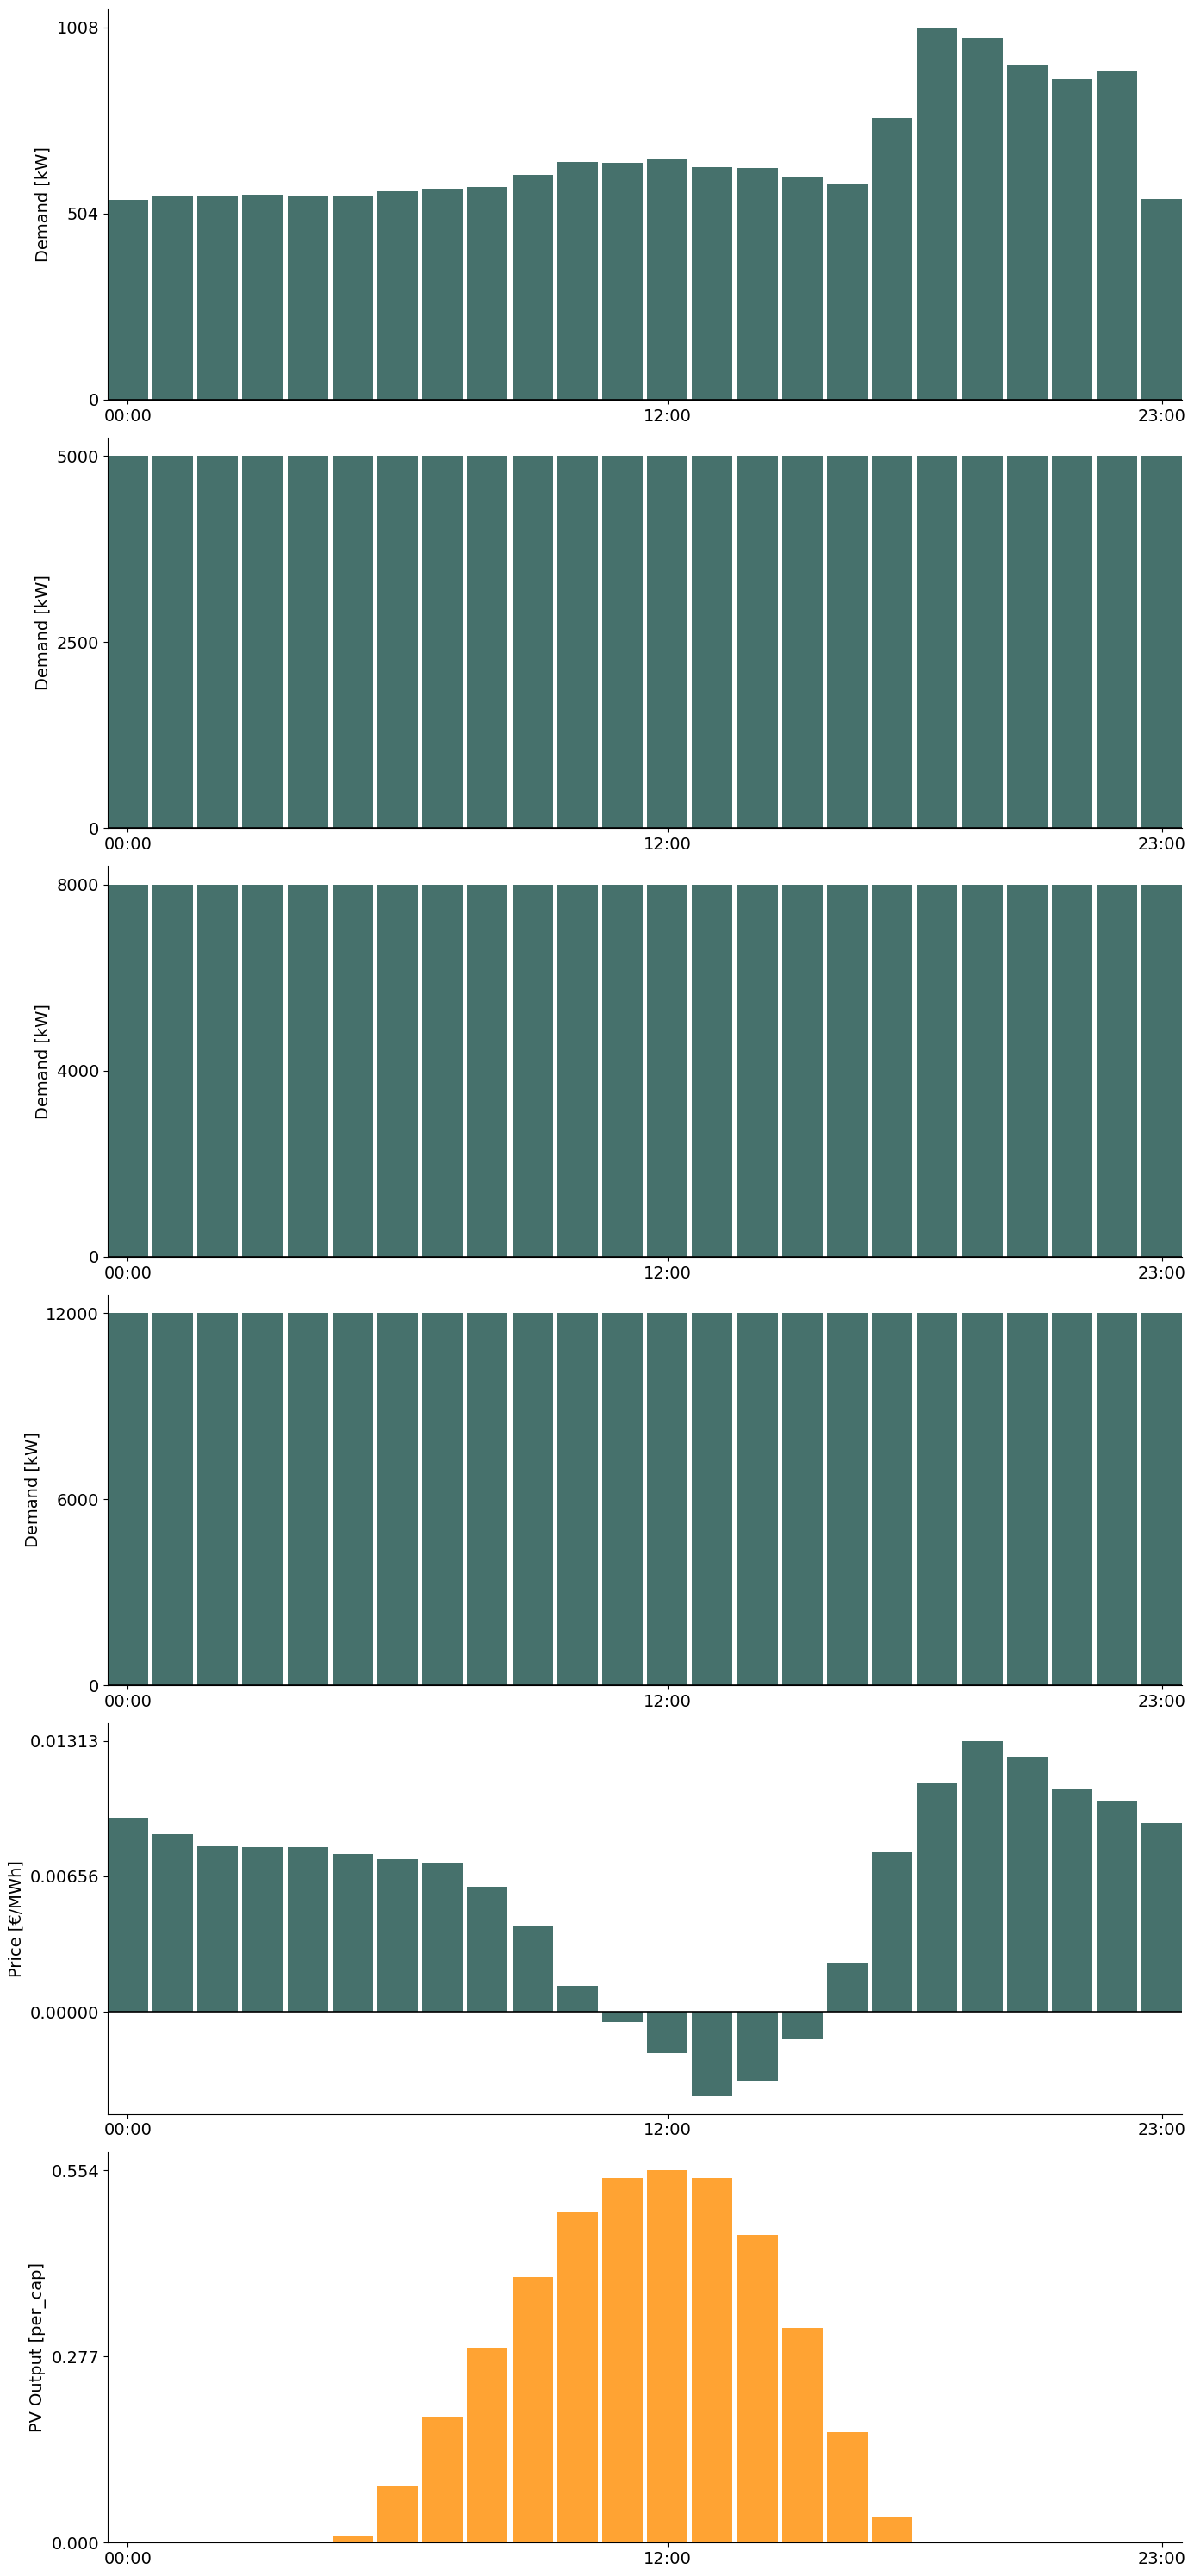

✓ Bar charts for 2024-09-01 created successfully
  - Demand columns: ['residential_demand', 'data_center_1', 'data_center_2', 'data_center_3']
  - Data points: 24


In [312]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load CSV files
demand_df = pd.read_csv('demand.csv', index_col=0, parse_dates=True, skiprows=1)
prices_df = pd.read_csv('day_ahead_prices.csv', index_col=0, parse_dates=True, skiprows=1)
pv_df = pd.read_csv('pv_resource.csv', index_col=0, parse_dates=True, skiprows=1)

# Rename demand columns
demand_df.columns = ['residential_demand', 'data_center_1', 'data_center_2', 'data_center_3']

# Filter for September 1st, 2024
target_date = '2024-09-01'
demand_sep1 = demand_df.loc[target_date]
prices_sep1 = prices_df.loc[target_date]
pv_sep1 = pv_df.loc[target_date]

# Convert to DataFrames if Series
if isinstance(demand_sep1, pd.Series):
    demand_sep1 = demand_sep1.to_frame().T
if isinstance(prices_sep1, pd.Series):
    prices_sep1 = prices_sep1.to_frame().T
if isinstance(pv_sep1, pd.Series):
    pv_sep1 = pv_sep1.to_frame().T

# Create subplots: 4 demand + 1 prices + 1 pv = 6 total
num_demand_plots = demand_sep1.shape[1]
total_plots = num_demand_plots + 2
fig, axes = plt.subplots(total_plots, 1, figsize=(14, 5.0 * total_plots))

if total_plots == 1:
    axes = [axes]
elif not isinstance(axes, np.ndarray):
    axes = np.array([axes])

# Plot demand charts
for idx, col in enumerate(demand_sep1.columns):
    ax = axes[idx]
    data = demand_sep1[col].values
    x_pos = np.arange(len(data))
    ax.bar(x_pos, data, color='#184e47', alpha=0.8, width=0.9)
    ax.axhline(y=0, color='black', linewidth=1.2, linestyle='-')
    ax.set_ylabel('Demand [kW]', fontsize=14)
    ax.set_xticks([0, 12, 23])
    ax.set_xticklabels(['00:00', '12:00', '23:00'], fontsize=14)
    ax.tick_params(axis='y', labelsize=14)
    # Set 3 y-ticks: 0, max/2, max
    y_max = data.max()
    ax.set_yticks([0, y_max / 2, y_max])
    ax.margins(x=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Plot prices
price_ax = axes[num_demand_plots]
price_data = prices_sep1.iloc[:, 0].values
x_pos = np.arange(len(price_data))
price_ax.bar(x_pos, price_data, color='#184e47', alpha=0.8, width=0.9)
price_ax.axhline(y=0, color='black', linewidth=1.2, linestyle='-')
price_ax.set_ylabel('Price [€/MWh]', fontsize=14)
price_ax.set_xticks([0, 12, 23])
price_ax.set_xticklabels(['00:00', '12:00', '23:00'], fontsize=14)
price_ax.tick_params(axis='y', labelsize=14)
# Set 3 y-ticks: 0, max/2, max
y_max = price_data.max()
price_ax.set_yticks([0, y_max / 2, y_max])
price_ax.margins(x=0)
price_ax.spines['top'].set_visible(False)
price_ax.spines['right'].set_visible(False)

# Plot PV
pv_ax = axes[num_demand_plots + 1]
pv_data = pv_sep1.iloc[:, 0].values
x_pos = np.arange(len(pv_data))
pv_ax.bar(x_pos, pv_data, color='darkorange', alpha=0.8, width=0.9)
pv_ax.axhline(y=0, color='black', linewidth=1.2, linestyle='-')
pv_ax.set_ylabel('PV Output [per_cap]', fontsize=14)
pv_ax.set_xticks([0, 12, 23])
pv_ax.set_xticklabels(['00:00', '12:00', '23:00'], fontsize=14)
pv_ax.tick_params(axis='y', labelsize=14)
# Set 3 y-ticks: 0, max/2, max
y_max = pv_data.max()
pv_ax.set_yticks([0, y_max / 2, y_max])
pv_ax.margins(x=0)
pv_ax.spines['top'].set_visible(False)
pv_ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print(f"✓ Bar charts for {target_date} created successfully")
print(f"  - Demand columns: {list(demand_sep1.columns)}")
print(f"  - Data points: {len(demand_sep1)}")